# 1. Ödevin amacı
Bu ödevde yemek tarifleri veri seti üzerinde temel metin ön işleme adımlarını (Zipf Yasası, metin temizleme, tokenizasyon, vb.) uygulayacağız.



In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import snowballstemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KEREM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KEREM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KEREM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KEREM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Veriyi JSON formatından okuma
with open('recipes_groq_cleaned.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [ ]:
# Dataframe ilk 1000
records = []
for recipe in data[:1000]:
    name = recipe.get('tarif_adi', '')
    kategori = recipe.get('kategori', '')
    ingredients = [ing.get('isim', '') for ing in recipe.get('malzemeler', []) if ing.get('isim')]
    instructions = recipe.get('yapilis_adimlari', [])
    records.append({
        'Tarif_Adi': name,
        'Kategori': kategori,
        'Malzemeler': ' '.join(ingredients),
        'Yapilis_Adimlari': ' '.join(instructions)
    })

df = pd.DataFrame(records)

In [ ]:
# Ham veri setini csv olarak kaydetme görme
df.to_csv('Ham_Veri_Seti.csv', index=False, encoding='utf-8')
print("Ham Veri Seti")
display(df.head())

Ham Veri Seti kaydedildi.


,Tarif_Adi,Kategori,Malzemeler,Yapilis_Adimlari
0,Sodalı Köfte,ana yemek,kıyma soğan galeta unu tuz kırmızı toz biber k...,Derin bir kap içine 1 adet büyük boy soğan ren...
1,Piliç Topkapı,ana yemek,tavuk but süt karabiber kırmızı toz biber tuz ...,Tavuk butlarını kasabınızdan rica ederek kemik...
2,Tire Şiş Köfte,ana yemek,orta yağlı kıyma tuz karabiber orta boy sivri ...,Derin bir kap içine yarım kilo orta yağlı kıym...
3,Et Köfte,ana yemek,kıyma yumurta kuru soğan galeta unu kimyon pul...,Derin bir kaba 350 gr kıyma koyun. Üzerine 1 a...
4,Şıhıl Mahşi,ana yemek,kabak kıyma nohut soğan sarımsak zeytinyağı ma...,Kabakları yıkayın ve uzun çizikler atın. Kabak...


# 3. Zipf yasası analizi


In [ ]:
# Kelime frekanslarının hesaplanması
all_text = ' '.join(df['Malzemeler'].astype(str))
words = re.findall(r'\w+', all_text.lower())
word_counts = Counter(words)

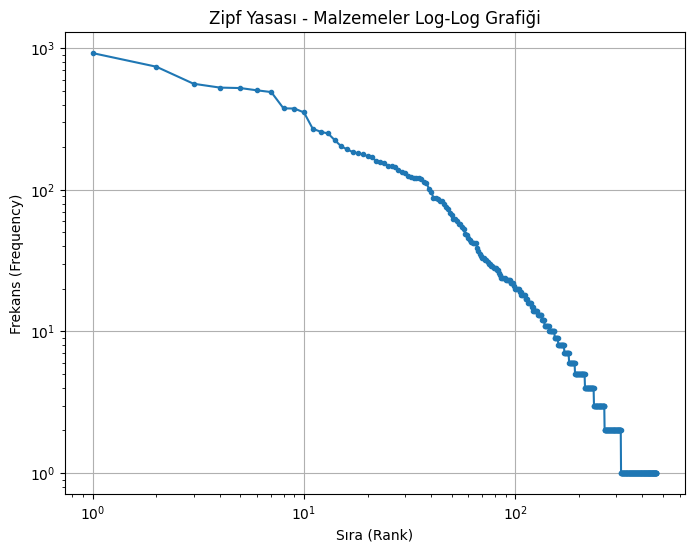

In [ ]:
# zipf yasası log-log grafiğinin çizdirilmesi
frequencies = sorted(list(word_counts.values()), reverse=True)
ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(8, 6))
plt.loglog(ranks, frequencies, marker='.')
plt.title("Zipf Yasası - Malzemeler Log-Log Grafiği")
plt.xlabel("Sıra (Rank)")
plt.ylabel("Frekans (Frequency)")
plt.grid(True)
plt.show()

# 4. Ön işleme aşamaları


### 4.1 Genel içerik temizlik
html etiketleri, özel karakterler, sayılar ve gereksiz semboller temizleme aşamalaar

In [ ]:
# temizleme fonk
def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text)) 
    text = re.sub(r'[^\w\s]', '', text) 
    text = re.sub(r'\d+', '', text) 
    return text

In [ ]:
# temizleme işleminin veriye uygulamak
df['cleaned'] = df['Malzemeler'].apply(clean_text)

In [ ]:
# İslem öncesi ve sonrası karşılastırma
print("Önce:")
print(df['Malzemeler'].iloc[0])
print("\nSonra:")
print(df['cleaned'].iloc[0])

Önce:
kıyma soğan galeta unu tuz kırmızı toz biber kırmızı pul biber kimyon karabiber kabartma tozu soda

Sonra:
kıyma soğan galeta unu tuz kırmızı toz biber kırmızı pul biber kimyon karabiber kabartma tozu soda


### 4.2 Lowercasing
Tüm metin küçük harfe dönüşturme.

In [ ]:
# lowercase işleminin uygulanması
df['lowercased'] = df['cleaned'].apply(lambda x: x.lower())

In [11]:
# İşlem öncesi ve sonrası karşılaştırma
print("Önce:")
print(df['cleaned'].iloc[0])
print("\nSonra:")
print(df['lowercased'].iloc[0])

Önce:
kıyma soğan galeta unu tuz kırmızı toz biber kırmızı pul biber kimyon karabiber kabartma tozu soda

Sonra:
kıyma soğan galeta unu tuz kırmızı toz biber kırmızı pul biber kimyon karabiber kabartma tozu soda


### 4.3 Tokenization
metnin kelimelere ayrılması işlemi (NLTK kutuphanesı).

In [ ]:
df['tokenized'] = df['lowercased'].apply(nltk.word_tokenize)

In [ ]:
# işlem öncesi ve sonrası karşılaştırma
print("Önce:")
print(df['lowercased'].iloc[0])
print("\nSonra:")
print(df['tokenized'].iloc[0])

Önce:
kıyma soğan galeta unu tuz kırmızı toz biber kırmızı pul biber kimyon karabiber kabartma tozu soda

Sonra:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']


### 4.4 Stop Word Removal
Dile ozgü (Türkçe) gereksiz kelimelerin çıkkarılması

In [ ]:
# Etkisiz kelimelerin silinmesi
stop_words = set(stopwords.words('turkish'))
df['no_stopwords'] = df['tokenized'].apply(lambda x: [word for word in x if word not in stop_words])

In [15]:
# İşlem öncesi ve sonrası karşılaştırma
print("Önce:")
print(df['tokenized'].iloc[0])
print("\nSonra:")
print(df['no_stopwords'].iloc[0])

Önce:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']

Sonra:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']


### 4.5 Lemmatization
Kelimelerin sözlük köklerine inmesi -indirgenmesi.

In [ ]:
# Lemmatization işlemi
lemmatizer = WordNetLemmatizer()
df['lemmatized'] = df['no_stopwords'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df['Lemmatized_Metin'] = df['lemmatized'].apply(lambda x: ' '.join(x))

In [ ]:
# lemmatized veriyi csv olarak kaydetme
df[['Tarif_Adi', 'Lemmatized_Metin']].to_csv('Lemmatized_Veri_Seti.csv', index=False, encoding='utf-8')
print("Lammatized Veri Seti")

Lemmatized Veri Seti kaydedildi.


In [ ]:
# İşlem öncesi ve sonrasi
print("Önce:")
print(df['no_stopwords'].iloc[0])
print("\nSonra:")
print(df['lemmatized'].iloc[0])

Önce:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']

Sonra:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']


### 4.6 Stemming
Kelimelerin eklerinden arındırılarak gövdeye indirgenmesi.

In [ ]:
# gövde bulma işleminin uygulanması
stemmer = snowballstemmer.stemmer('turkish')
df['stemmed'] = df['no_stopwords'].apply(lambda x: [stemmer.stemWord(word) for word in x])
df['Stemmed_Metin'] = df['stemmed'].apply(lambda x: ' '.join(x))

In [ ]:
# stemmed veriyi csv olarak kaydetme
df[['Tarif_Adi', 'Stemmed_Metin']].to_csv('Stemmed_Veri_Seti.csv', index=False, encoding='utf-8')
print("Stemmed Veri Seti")

Stemmed Veri Seti kaydedildi.


In [ ]:
# işlem öncesi ve sonrası
print("Önce:")
print(df['no_stopwords'].iloc[0])
print("\nSonra:")
print(df['stemmed'].iloc[0])

Önce:
['kıyma', 'soğan', 'galeta', 'unu', 'tuz', 'kırmızı', 'toz', 'biber', 'kırmızı', 'pul', 'biber', 'kimyon', 'karabiber', 'kabartma', 'tozu', 'soda']

Sonra:
['kıyma', 'soğa', 'gale', 'un', 'tuz', 'kırmız', 'toz', 'biber', 'kırmız', 'pul', 'biber', 'kimyo', 'karabiber', 'kabartma', 'toz', 'so']


# 5. Yemek tarifi eşleştirme sistemi
Girilen malzeme listesine en uygun 3 tarifi bulma işlemi.

### 5.1 TF-IDF Modelinin oluşturma
Tariflerin tf-idf vektörlerinin çıkarılması işlemleri.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#TF-IDF vektörleştirici oluşturmak (Stemlenmiş veriler üzerinde)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Stemmed_Metin'])

### 5.2 Eşleştirme fonksiyonunun tanımlanması
kullanıcıdan alınan malzemeleri kulanarak en benzer tarifleri getiren fonks.

In [ ]:
def onerilen_tarifler(kullanici_malzemeleri, df, vectorizer, tfidf_matrix, top_n=3):
   
    temiz_girdi = clean_text(kullanici_malzemeleri).lower()
    token_girdi = nltk.word_tokenize(temiz_girdi)
    stem_girdi = ' '.join([stemmer.stemWord(word) for word in token_girdi if word not in stop_words])
    # kullanıcı girdisini vektörleştirmw
    girdi_vec = vectorizer.transform([stem_girdi])
    
    similarities = cosine_similarity(girdi_vec, tfidf_matrix).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    sonuclar = []
    for idx in top_indices:
        sonuclar.append({
            'Tarif': df.iloc[idx]['Tarif_Adi'],
            'Skor': similarities[idx],
            'Malzemeler': df.iloc[idx]['Malzemeler']
        })
    return sonuclar

### 5.3 örnek test
sistemin örnek bir malzeme lisstesi ile test edilmesi.

In [ ]:
# Örnek test
kullanici_girisi = "kıyma soğan galeta unu kırmızı biber"
print(f"Kullanıcı Malzemeleri: {kullanici_girisi}\n")

oneriler = onerilen_tarifler(kullanici_girisi, df, vectorizer, tfidf_matrix)
for i, oneri in enumerate(oneriler, 1):
    print(f"{i}. Öneri: {oneri['Tarif']}")
    print(f"Benzerlik Skoru: {oneri['Skor']:.4f}")
    print(f"Tarifin Malzemeleri: {oneri['Malzemeler']}\n")